In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/baojianing/.cache/kagglehub/datasets/maharshipandya/-spotify-tracks-dataset/versions/1


In [2]:
import os
os.listdir(path)  # find the file name so we can read it into a dataframe

['dataset.csv']

In [55]:
# import data and display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv(path + '/dataset.csv')
df = data.copy()
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
dfsp = df.drop(columns = 'Unnamed: 0')  # drop the first column, which is unnecessary
dfsp = dfsp.drop_duplicates()  # remove duplicates
dfsp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113550 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113550 non-null  object 
 1   artists           113549 non-null  object 
 2   album_name        113549 non-null  object 
 3   track_name        113549 non-null  object 
 4   popularity        113550 non-null  int64  
 5   duration_ms       113550 non-null  int64  
 6   explicit          113550 non-null  bool   
 7   danceability      113550 non-null  float64
 8   energy            113550 non-null  float64
 9   key               113550 non-null  int64  
 10  loudness          113550 non-null  float64
 11  mode              113550 non-null  int64  
 12  speechiness       113550 non-null  float64
 13  acousticness      113550 non-null  float64
 14  instrumentalness  113550 non-null  float64
 15  liveness          113550 non-null  float64
 16  valence           113550 

#### 💡 Problem and challenge here: 
--It was hard to define which can be the duplicate. 

--We considered: track id, [artist, track name, album name]. At the end we decided to go for all columns, because this is the safest way.

In [5]:
dfsp = dfsp.dropna()  # remove rows with missing values
dfsp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113549 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113549 non-null  object 
 1   artists           113549 non-null  object 
 2   album_name        113549 non-null  object 
 3   track_name        113549 non-null  object 
 4   popularity        113549 non-null  int64  
 5   duration_ms       113549 non-null  int64  
 6   explicit          113549 non-null  bool   
 7   danceability      113549 non-null  float64
 8   energy            113549 non-null  float64
 9   key               113549 non-null  int64  
 10  loudness          113549 non-null  float64
 11  mode              113549 non-null  int64  
 12  speechiness       113549 non-null  float64
 13  acousticness      113549 non-null  float64
 14  instrumentalness  113549 non-null  float64
 15  liveness          113549 non-null  float64
 16  valence           113549 

##### 💡 Now the data cleaning step is end. 

In [6]:
# export as CSV file, later for sql part
dfsp.to_csv("/Users/baojianing/Desktop/DS ML 2026 June_J Bao/3_week/project_week 3/spotify.csv", index=False)

### ⚙️ Univariate analysis: duration

In [7]:
#duration is as duration_ms
dfsp["duration_ms"].describe().reset_index().round(0)  # describe the duration_ms column

,index,duration_ms
0,count,113549.0
1,mean,228081.0
2,std,106413.0
3,min,8586.0
4,25%,174184.0
5,50%,213000.0
6,75%,261588.0
7,max,5237295.0


#### The duration_ms column in milliseconds is not very interpretable. It should be converted to seconds.

In [35]:
dfsp['duration_s'] = dfsp['duration_ms'] / 1000 # convert to seconds that is more interpretable
dfsp['duration_s'].describe().round(0).reset_index(name = 'duration / s') 

,index,duration / s
0,count,113549.0
1,mean,228.0
2,std,106.0
3,min,9.0
4,25%,174.0
5,50%,213.0
6,75%,262.0
7,max,5237.0


Before go for data cleaning, the original distribution is displayed here: 

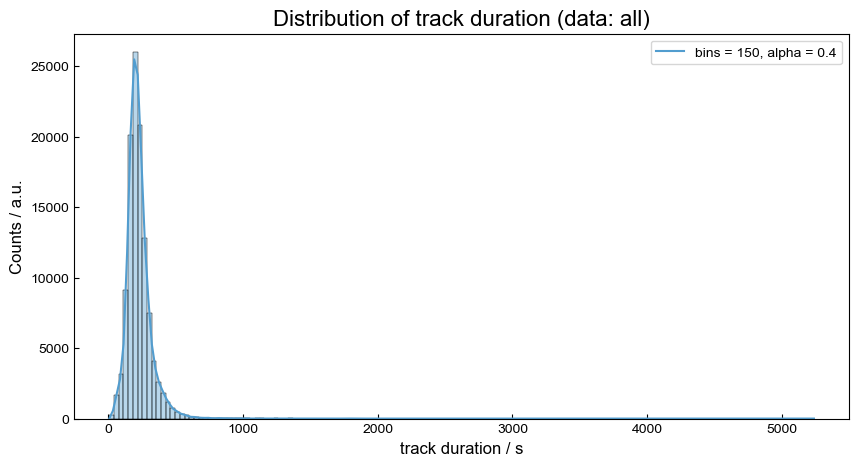

In [36]:
plt.figure(figsize=(10, 5))
plt.rcParams['font.family']= 'arial'
plt.tick_params(axis='both', direction='in')
sns.histplot(x=dfsp["duration_s"], bins=150, kde=True, color="#529DCF", alpha=0.4)
plt.title("Distribution of track duration (data: all)", fontsize=16)
plt.xlabel("track duration / s", fontsize=12)
plt.ylabel("Counts / a.u.", fontsize=12)
plt.legend(['bins = 150, alpha = 0.4'])
plt.show()

If we look into the x range 0 to 800: 

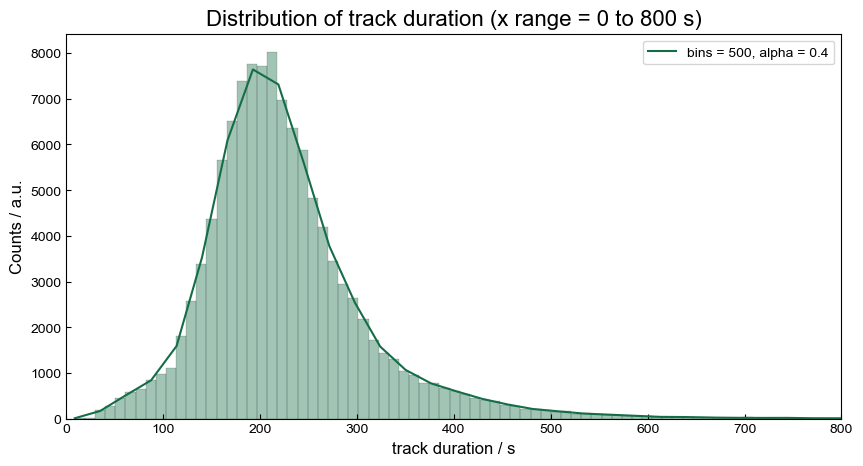

In [37]:
plt.figure(figsize=(10,5))
plt.rcParams['font.family']= 'arial'
plt.tick_params(axis='both', direction='in')
sns.histplot(x=dfsp["duration_s"], bins=500, kde=True, color="#156D47", alpha=0.4)
plt.title("Distribution of track duration (x range = 0 to 800 s)", fontsize=16)
plt.xlabel("track duration / s", fontsize=12)
plt.ylabel("Counts / a.u.", fontsize=12)
plt.legend(['bins = 500, alpha = 0.4'])
plt.xlim(0,800)
plt.show()

It is clear that the most of the data points locate in this range. 

/var/folders/63/dzhzcn696dbdv60g_f7p4wb80000gn/T/ipykernel_39590/3434162064.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=dfsp["duration_s"], palette="pastel")


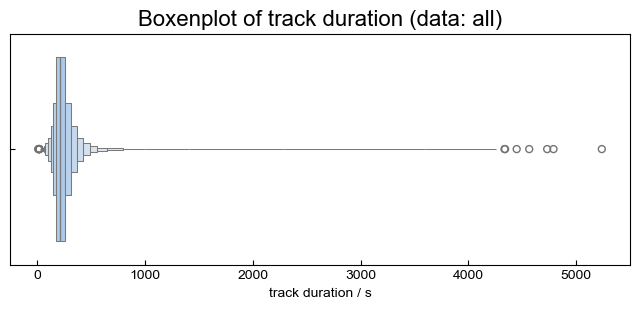

In [38]:
plt.figure(figsize=(8, 3))
plt.rcParams['font.family']= 'arial'
plt.tick_params(axis='both', direction='in')
sns.boxenplot(x=dfsp["duration_s"], palette="pastel")
plt.title("Boxenplot of track duration (data: all)", fontsize=16)
plt.xlabel("track duration / s")
plt.show()

Boxenplot also shows some outliers on the right side. 

#### Insights: 
As we can see: There are outliers on the right side, which should be removed.

What can outlier be: Extremely long tracks can be e.g. podcast, live recording etc, not a song. 

Since we are analyzing the music tracks herem, the outliers should be removed before next steps. 

Next step: calculate IQR, Q1 and Q3 to see which outlier should be removed.

In [12]:
# calculate IQR,  Q1 and Q3
Q1_duration = dfsp['duration_s'].quantile(0.25)
Q3_duration = dfsp['duration_s'].quantile(0.75)
IQR_duration = Q3_duration - Q1_duration
lower = Q1_duration - 1.5 * IQR_duration
upper = Q3_duration + 1.5 * IQR_duration    
dfsp_duration_clean = dfsp[(dfsp['duration_s'] >= lower) & (dfsp['duration_s'] <= upper)]
dfsp_duration_clean.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_s
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,230.666
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,149.610
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,210.826
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,201.933
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,198.853


#### Now if we look at the boxplot, it is obviously that outliers are already removed. 

/var/folders/63/dzhzcn696dbdv60g_f7p4wb80000gn/T/ipykernel_39590/3411120923.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=dfsp_duration_clean["duration_s"],palette="pastel", alpha=0.7, showfliers=False)


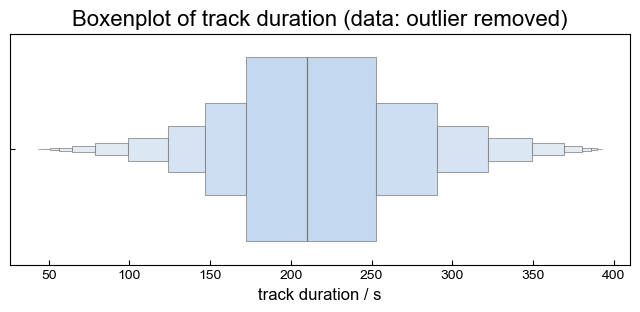

In [13]:
plt.figure(figsize=(8, 3))
plt.rcParams['font.family']= 'arial'
plt.tick_params(axis='both', direction='in')
sns.boxenplot(x=dfsp_duration_clean["duration_s"],palette="pastel", alpha=0.7, showfliers=False)
plt.title("Boxenplot of track duration (data: outlier removed)",    fontsize=16)
plt.xlabel("track duration / s", fontsize=12)
plt.show()

In [39]:
# look at the details now:
dfsp_duration_clean['duration_s'].describe().round(0).reset_index(name = 'duration / s')

,index,duration / s
0,count,107957.0
1,mean,215.0
2,std,64.0
3,min,43.0
4,25%,172.0
5,50%,210.0
6,75%,253.0
7,max,393.0


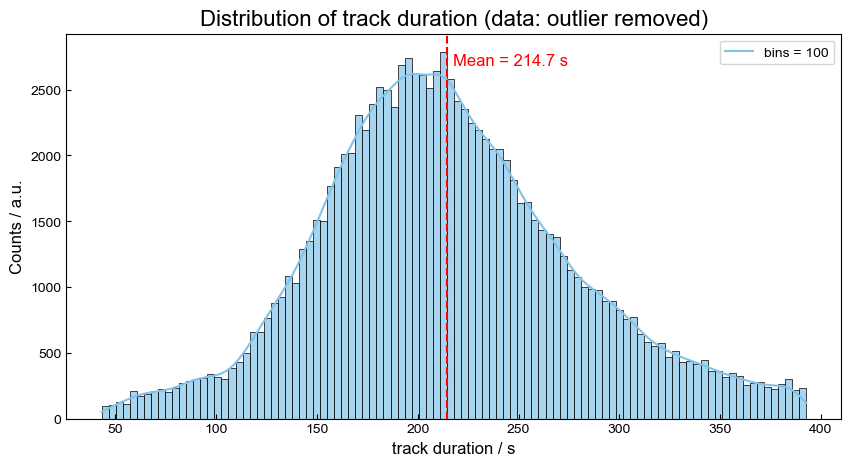

In [ ]:
# draw distribution now: (with average value)
plt.figure(figsize=(10, 5))
plt.rcParams['font.family']= 'arial'
plt.tick_params(axis='both', direction='in')

sns.histplot(x=dfsp_duration_clean["duration_s"], bins=100, kde=True, color="#82C3E9", alpha=0.7)
mean_duration = dfsp_duration_clean['duration_s'].mean()

plt.axvline(mean_duration,
            color='red',
            linestyle='--',
            linewidth=1.5)

plt.text(mean_duration + 3,                # right side of the mean line
         plt.ylim()[1]*0.95,      # near the top of the y-axis
         f'Mean = {mean_duration:.1f} s',
         color='red',
         fontsize=12,
         ha='left',               # text from left
         va='top')               
plt.title("Distribution of track duration (data: outlier removed)", fontsize=16)
plt.xlabel("track duration / s", fontsize=12)
plt.ylabel("Counts / a.u.", fontsize=12)
plt.legend(["bins = 100"])
plt.show()

In [16]:
dfsp_duration_clean['duration_s'].skew().round(2)  # skewness of the distribution


np.float64(0.28)

##### If we caculate the skewness: 
slightly right skewed distribution, close to normal distribution.

The distribution after removing the outliers is close to normal distribution. 

In [43]:
dfsp_duration_clean["duration_s"].kurt().round(2)  # kurtosis of the distribution

np.float64(0.1)

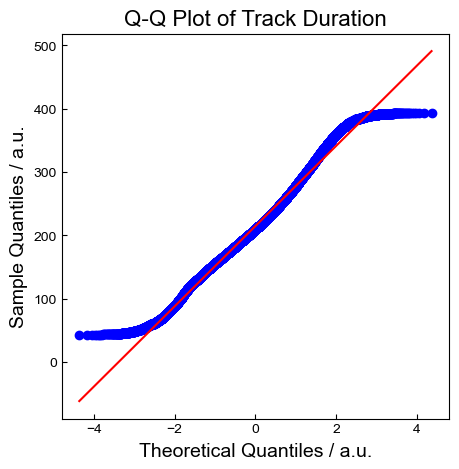

In [18]:
from scipy import stats
plt.figure(figsize=(5, 5))
plt.rcParams['font.family']= 'arial'

stats.probplot(dfsp_duration_clean["duration_s"], plot=plt)

plt.title("Q-Q Plot of Track Duration", fontsize=16)
plt.xlabel("Theoretical Quantiles / a.u.", fontsize=14)
plt.ylabel("Sample Quantiles / a.u.", fontsize=14)
plt.tick_params(axis='both', direction='in')
plt.show()

### ⚙️ Bivariate analysis

In [45]:
# start bivariate analysis
dfsp.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_s
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,230.666
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,149.610
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,210.826
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,201.933
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,198.853


#### my part: to check if there is a correlation between explicit and other parameters

At first, the single variable "explicit" will be checked to see how many explicit songs are there in the dataset.

#### Explicit:

In [52]:
dfsp['explicit'].value_counts()

explicit
False    103831
True       9718
Name: count, dtype: int64

/var/folders/63/dzhzcn696dbdv60g_f7p4wb80000gn/T/ipykernel_39590/3275412794.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dfsp['explicit'], palette="Set2", alpha=0.7)


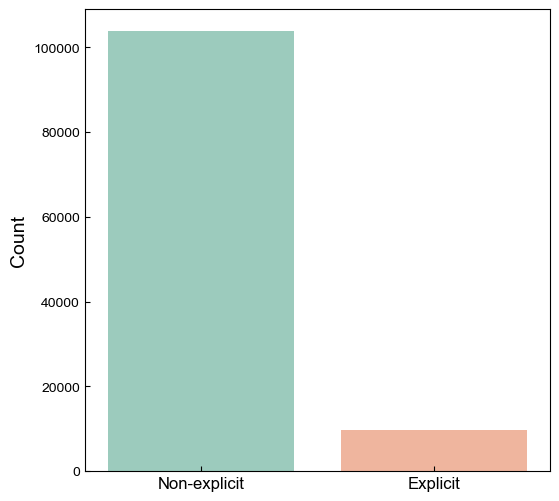

In [ ]:
# bar plot to display how many songs are with "E" in the whole dataset
plt.figure(figsize=(6, 6))
plt.rcParams['font.family']= 'arial'

sns.countplot(x=dfsp['explicit'], palette="Set2", alpha=0.7)
plt.xticks([0, 1], ["Non-explicit", "Explicit"], fontsize=12)
plt.xlabel('')
plt.ylabel("Count", fontsize=14)
plt.tick_params(axis='both', direction='in')
plt.show()

--- Here the barplot is not so clear to demonstrate the difference, so I choose to add a pie chart here. 

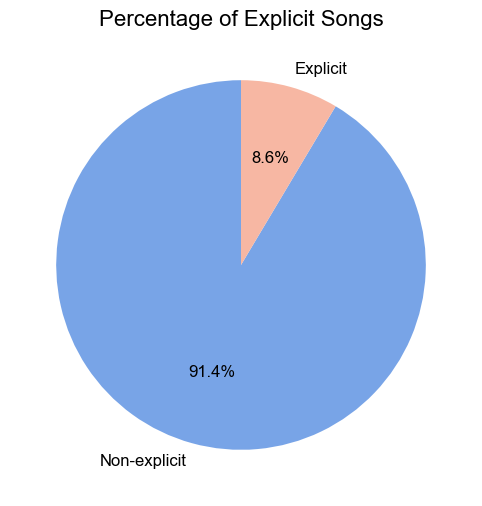

In [23]:
# pie chart
plt.figure(figsize=(12, 6))
plt.rcParams['font.family']= 'arial'
labels = ['Non-explicit', 'Explicit']
dfsp['explicit'].value_counts().plot.pie(labels = labels,autopct='%1.1f%%', colors=[ "#78A4E7","#F7B7A3"], startangle=90, textprops={'fontsize': 12})   

plt.title("Percentage of Explicit Songs", fontsize=16)
plt.xlabel('')
plt.ylabel('')

plt.show()

#### Insights: 

The songs contained "E" among the dataset takes 8.6 %, actually is not that much. The most of the songs are without explicit words.

#### If we observe explicit & track genre, is there any correletion?

In [53]:
# categorical vs categorical. explicit vs track_genre
cross1 = pd.crosstab(dfsp['track_genre'], dfsp['explicit']).reset_index(names = 'track genre')
cross1_pct = cross1.copy()
cross1_pct["explicit in %"] = ((cross1_pct[True] / (cross1_pct[True] + cross1_pct[False])) * 100).round(2)
cross1_pct = cross1_pct.sort_values(by = "explicit in %", ascending = False)
cross1_pct.head(20)


explicit,track genre,False,True,explicit in %
18,comedy,343,653,65.56
33,emo,535,465,46.50
94,sad,550,450,45.00
60,j-dance,607,386,38.87
48,hardcore,674,325,32.53
51,hip-hop,677,314,31.69
37,funk,696,304,30.40
21,dancehall,697,302,30.23
72,metalcore,709,291,29.10
22,death-metal,748,251,25.13


In [25]:
# not important
cross1_true = cross1.sort_values(by = False, ascending = True)
cross1_true.head(20)

explicit,track genre,False,True
18,comedy,343,653
33,emo,535,465
94,sad,550,450
60,j-dance,607,386
48,hardcore,674,325
51,hip-hop,677,314
37,funk,696,304
21,dancehall,697,302
72,metalcore,709,291
68,latino,745,248


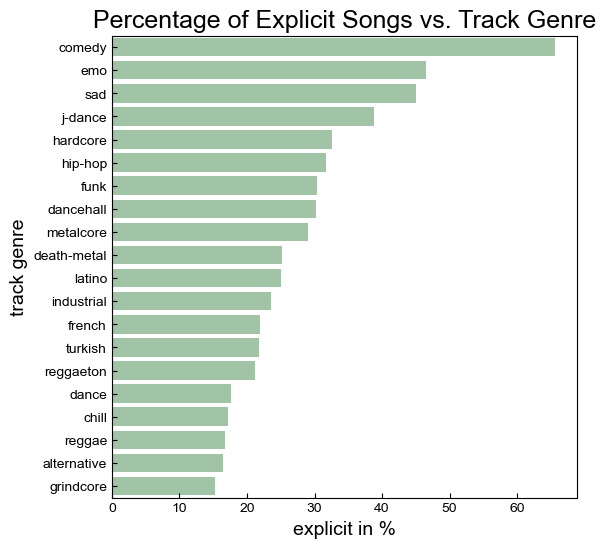

In [26]:
# plot the top 20 track genres with the highest percentage of explicit songs
cross1_pct_20 = cross1_pct.head(20)

plt.figure(figsize=(6, 6))
plt.rcParams['font.family']= 'arial'

sns.barplot(y = "track genre", x = "explicit in %", data = cross1_pct_20, color = "#72B27B", alpha = 0.7)

plt.title("Percentage of Explicit Songs vs. Track Genre", fontsize=18)
plt.xlabel("explicit in %", fontsize=14)
plt.ylabel("track genre", fontsize=14)
plt.tick_params(axis='both', direction='in')
plt.show()

#### Insights:

This is very interesting. The top 1 is comedy. The percentage is even more than 50 %. 

But basically the top 20 shown here is consistent with the common perception that rap/hip-hop music often contains explicit content.

In [54]:
cross2 = pd.crosstab(dfsp['popularity'],dfsp['explicit'])
cross2_true = cross2.copy()
cross2_true["explicit in %"] = ((cross2_true[True] / (cross2_true[True] + cross2_true[False])) * 100).round(2)
cross2_true.head(20)

explicit,False,True,explicit in %
popularity,,,
0,14549,1294,8.17
1,1892,224,10.59
2,908,117,11.41
3,503,67,11.75
4,321,56,14.85
5,568,24,4.05
6,405,14,3.34
7,448,7,1.54
8,524,14,2.60


In [28]:
cross2_true.info() # only show info, not important

<class 'pandas.core.frame.DataFrame'>
Index: 101 entries, 0 to 100
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   False          101 non-null    int64  
 1   True           101 non-null    int64  
 2   explicit in %  101 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 3.2 KB


#### What about explicit vs. popularity? Is the song more popular, contains also more "E" words?

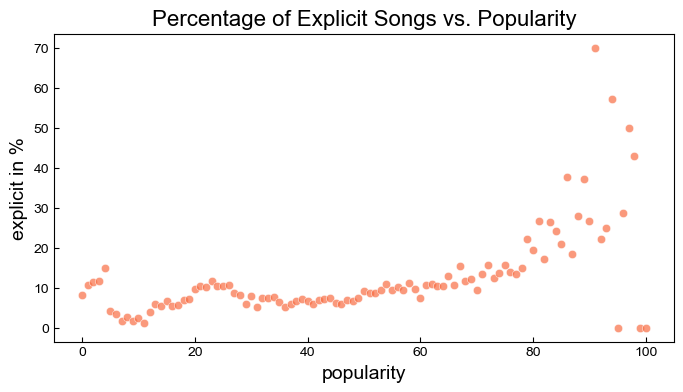

In [29]:
# plot explicit in % vs. popularity with scatter plot
plt.figure(figsize=(8, 4))
plt.rcParams['font.family']= 'arial'

sns.scatterplot(x = "popularity", y = "explicit in %", data = cross2_true, color = "#F86E44", alpha = 0.7)

plt.title("Percentage of Explicit Songs vs. Popularity", fontsize=16)
plt.xlabel("popularity", fontsize=14)
plt.ylabel("explicit in %", fontsize=14)
plt.tick_params(axis='both', direction='in')
plt.show()

In [30]:
# let me try groupby
gp_explicit = (dfsp.groupby('popularity')['explicit'].mean() * 100).round(2).reset_index(name = 'explicit in %')

gp_explicit.head(20)

,popularity,explicit in %
0,0,8.17
1,1,10.59
2,2,11.41
3,3,11.75
4,4,14.85
5,5,4.05
6,6,3.34
7,7,1.54
8,8,2.60
9,9,1.72


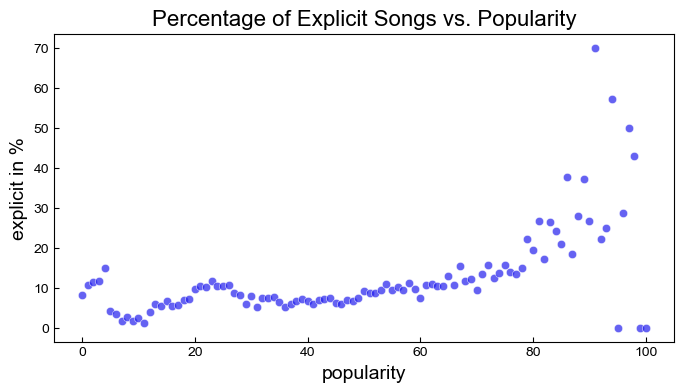

In [31]:
# actually same group
plt.figure(figsize=(8, 4))
plt.rcParams['font.family']= 'arial'
sns.scatterplot(x = "popularity", y = "explicit in %", data = gp_explicit, color = "#2420ED", alpha = 0.7)

plt.title("Percentage of Explicit Songs vs. Popularity", fontsize=16)
plt.xlabel("popularity", fontsize=14)
plt.ylabel("explicit in %", fontsize=14)
plt.tick_params(axis='both', direction='in')
plt.show()

#### Insights:
Actually both methods deliver the same result.

With the poularity increasing, the songs containing explicit words are slightly increasing, but for the most popular songs the data are highly unstable, which is hard to explain the relationship. 




In [32]:
# start another part: e.g. explicit vs. tempo
cross3 = pd.crosstab(dfsp['tempo'],dfsp['explicit']).reset_index(names = 'tempo')
cross3_true = cross3.copy()
cross3_true["explicit in %"] = ((cross3_true[True] / (cross3_true[True] + cross3_true[False])) * 100).round(2)
cross3_true.tail(20)

explicit,tempo,False,True,explicit in %
45632,214.016,1,0,0.0
45633,214.024,8,0,0.0
45634,214.864,1,0,0.0
45635,215.149,2,0,0.0
45636,215.513,3,0,0.0
45637,216.108,1,0,0.0
45638,216.334,1,0,0.0
45639,216.558,1,0,0.0
45640,217.228,1,0,0.0
45641,217.282,1,0,0.0


Insights: 
There is no obvious relationship between tempo an explicit. 

### To be conclude: 

Our exploratory data analysis provided a better understanding of the Spotify dataset and identified several interesting patterns. Although popularity is slightly associated with explicit songs, no strong relationship was observed for other features such as tempo. More advanced analysis or machine learning models may help explain these relationships more effectively.